In [ ]:

!pip install kaggle

from google.colab import files
files.upload()

!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d pavansubhasht/ibm-hr-analytics-attrition-dataset
!unzip ibm-hr-analytics-attrition-dataset.zip

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (1).csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
License(s): DbCL-1.0
100% 50.1k/50.1k [00:00<00:00, 19.8MB/s]

Archive:  ibm-hr-analytics-attrition-dataset.zip
replace WA_Fn-UseC_-HR-Employee-Attrition.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("✅ Dataset Loaded!")
print(f"Shape: {df.shape}")
df.head()

✅ Dataset Loaded!
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
print("=== Dataset Info ===")
print(f"Total Employees: {len(df)}")
print(f"Total Columns: {df.shape[1]}")
print(f"\nNull Values:\n{df.isnull().sum().sum()} (Total)")
print(f"\nAttrition Count:\n{df['Attrition'].value_counts()}")
print(f"\nAttrition Rate: {round(df['Attrition'].value_counts(normalize=True)['Yes']*100, 2)}%")

=== Dataset Info ===
Total Employees: 1470
Total Columns: 35

Null Values:
0 (Total)

Attrition Count:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


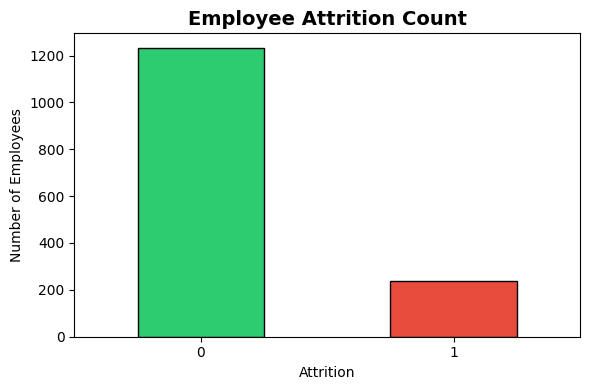

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(6,4))
colors = ['#2ecc71','#e74c3c']
df['Attrition'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Employee Attrition Count', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('Employee Attrition Countt.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('Employee Attrition Countt.png')

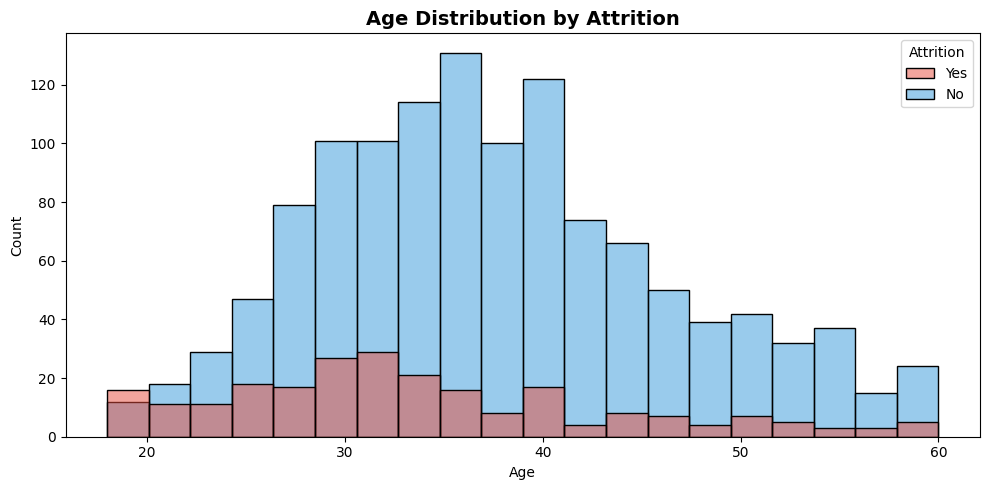

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Age', hue='Attrition', bins=20,
             palette={'Yes':'#e74c3c','No':'#3498db'})
plt.title('Age Distribution by Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

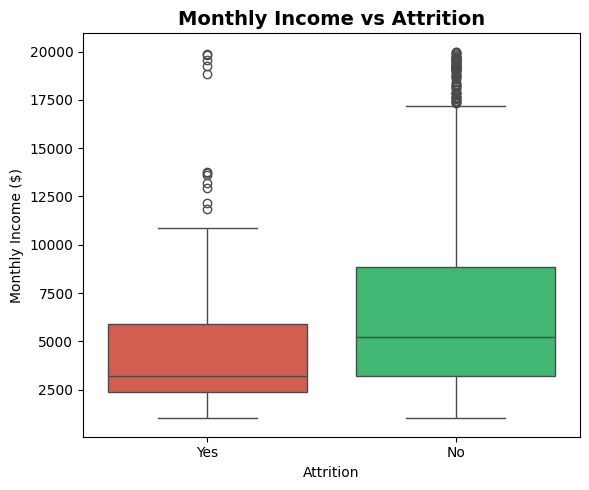

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,
            palette={'Yes':'#e74c3c','No':'#2ecc71'})
plt.title('Monthly Income vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income ($)')
plt.tight_layout()
plt.show()

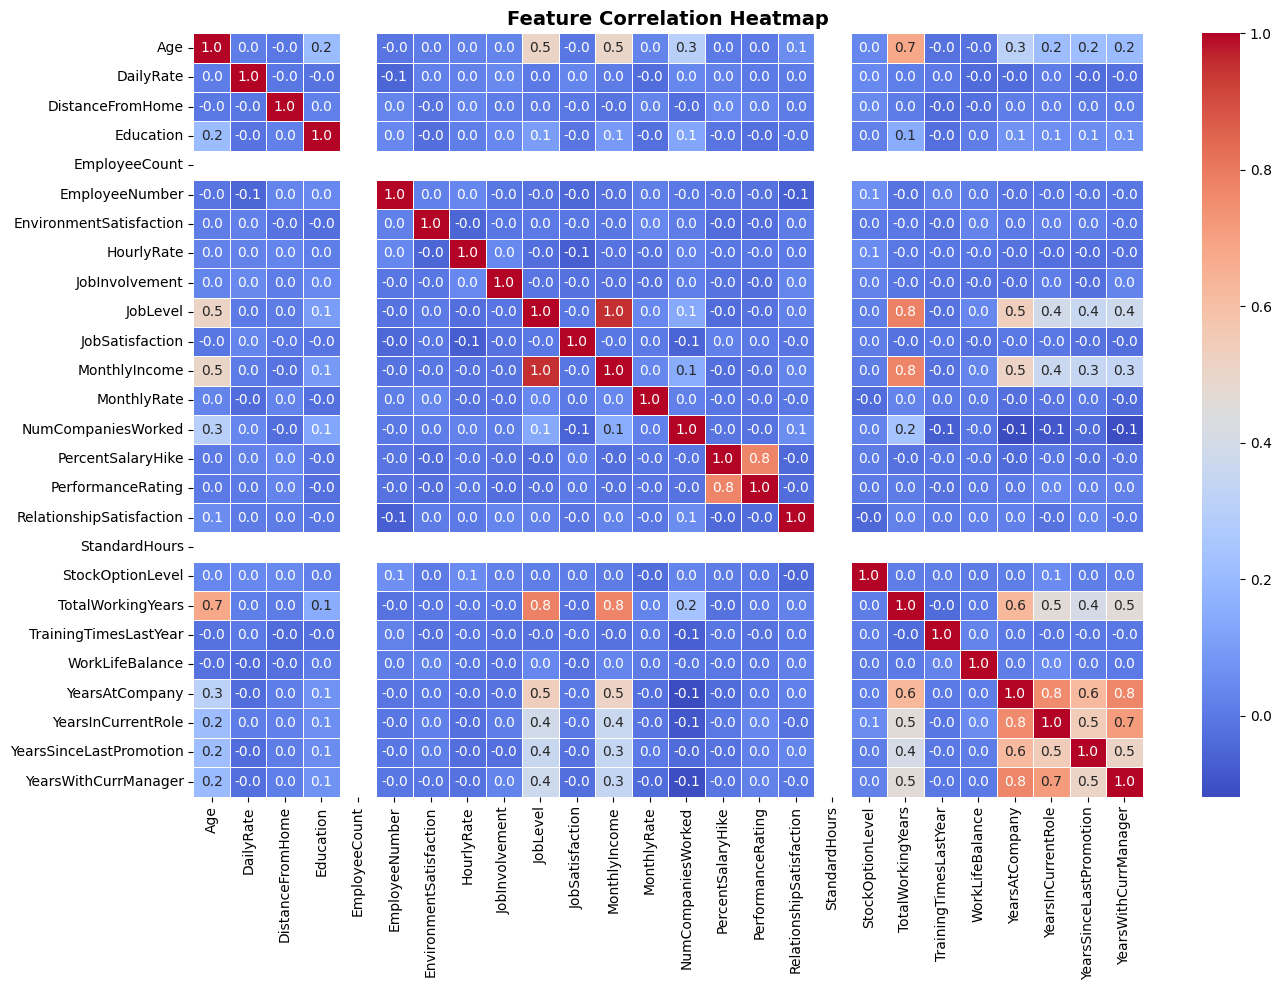

In [ ]:
plt.figure(figsize=(14,10))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.1f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"✅ Data Loaded | Shape: {df.shape}")
df.head()

✅ Data Loaded | Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
# These columns have same value for every row — useless for ML
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(cols_to_drop, axis=1)

print(f"✅ Dropped {len(cols_to_drop)} useless columns")
print(f"New Shape: {df.shape}")

✅ Dropped 4 useless columns
New Shape: (1470, 31)


In [ ]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['OverTime']  = df['OverTime'].map({'Yes': 1, 'No': 0})
df['Gender']    = df['Gender'].map({'Male': 1, 'Female': 0})

print("✅ Converted Yes/No columns to 1/0")
print(df[['Attrition','OverTime','Gender']].head())

✅ Converted Yes/No columns to 1/0
   Attrition  OverTime  Gender
0          1         1       0
1          0         0       1
2          1         1       1
3          0         1       0
4          0         0       1


In [ ]:
cat_cols = ['BusinessTravel', 'Department',
            'EducationField', 'JobRole', 'MaritalStatus']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("✅ Encoded all text columns")
print(f"\nFinal Data Types:")
print(df.dtypes.value_counts())

✅ Encoded all text columns

Final Data Types:
int64    31
Name: count, dtype: int64


In [ ]:
print("=== Final Dataset Check ===")
print(f"Shape: {df.shape}")
print(f"Null Values: {df.isnull().sum().sum()}")
print(f"Attrition Balance:\n{df['Attrition'].value_counts()}")
df.head()

=== Final Dataset Check ===
Shape: (1470, 31)
Null Values: 0
Attrition Balance:
Attrition
0    1233
1     237
Name: count, dtype: int64


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [ ]:
df.to_csv('cleaned_attrition.csv', index=False)
print("✅ Cleaned data saved as cleaned_attrition.csv")

✅ Cleaned data saved as cleaned_attrition.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
import shap

print("✅ All libraries imported!")

✅ All libraries imported!


In [ ]:
df = pd.read_csv('cleaned_attrition.csv')
print(f"✅ Data Loaded | Shape: {df.shape}")
df.head()

✅ Data Loaded | Shape: (1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [ ]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"\nAttrition Balance:\n{y.value_counts()}")

Features (X): (1470, 30)
Target (y): (1470,)

Attrition Balance:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Split Done!")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

✅ Split Done!
Train: (1176, 30) | Test: (294, 30)


In [ ]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)
print("✅ Model Trained!")

✅ Model Trained!


In [ ]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"✅ Model Accuracy: {accuracy*100:.2f}%")
print(f"\n=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=['Stay','Leave']))

✅ Model Accuracy: 86.05%

=== Classification Report ===
              precision    recall  f1-score   support

        Stay       0.87      0.98      0.92       247
       Leave       0.67      0.26      0.37        47

    accuracy                           0.86       294
   macro avg       0.77      0.62      0.65       294
weighted avg       0.84      0.86      0.83       294



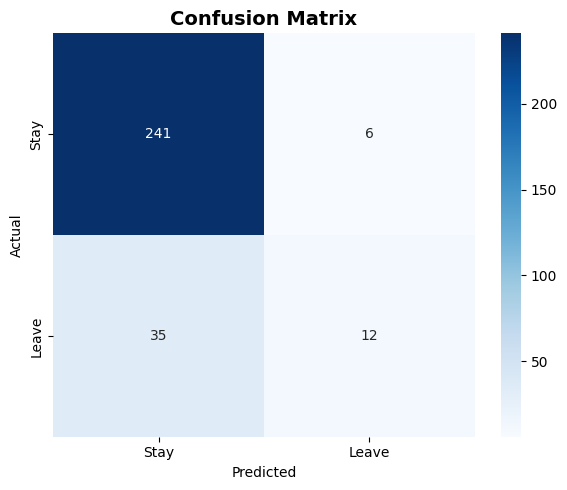

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay','Leave'],
            yticklabels=['Stay','Leave'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

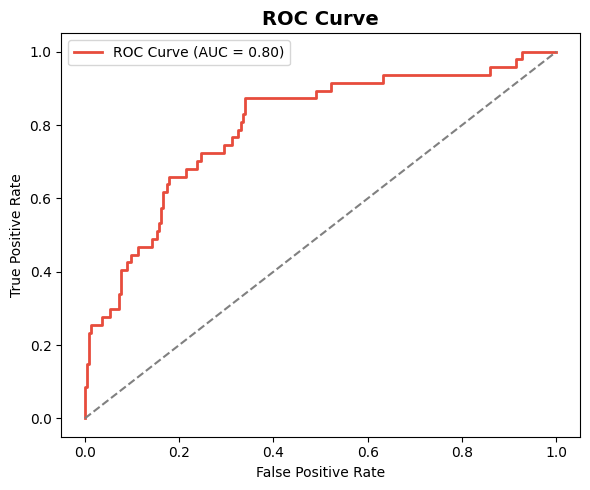

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2,
         label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

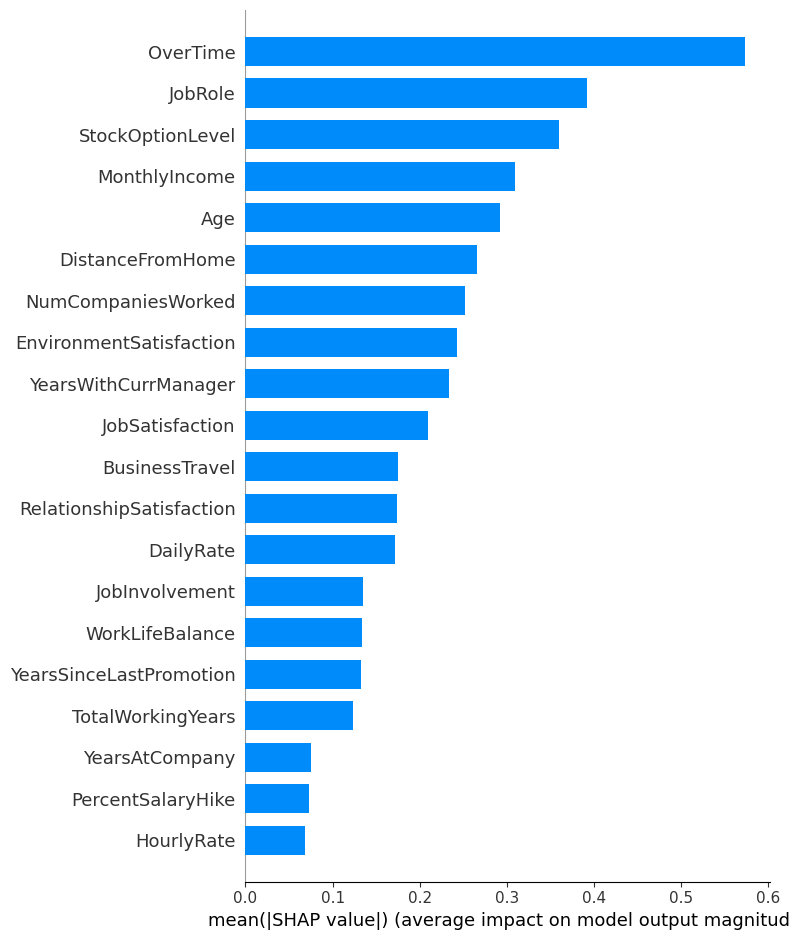

Text(0.5, 1.0, 'Top Features Predicting Attrition')

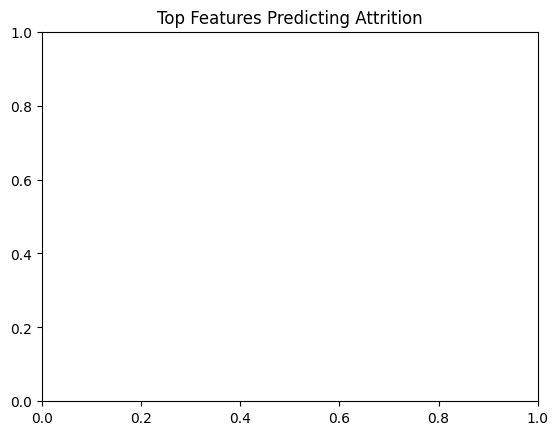

In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test,
                  plot_type="bar",
                  show=True)
plt.title('Top Features Predicting Attrition')

In [ ]:
with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✅ Model saved as xgboost_model.pkl")
print("✅ hr-attrition.ipynb")


✅ Model saved as xgboost_model.pkl
✅ hr-attrition.ipynb


In [ ]:
import zipfile
import os
from google.colab import files

with zipfile.ZipFile('hr_attrition_plots.zip', 'w') as zipf:
    for file in os.listdir('.'):
        if file.endswith('.png'):
            zipf.write(file)

files.download('hr_attrition_plots.zip')
print("✅ All plots downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All plots downloaded!
